<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/pca_demo_practice_ml_day_47_48.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
np.random.seed(23)

mu1_vec=np.array([0,0,0])
cov1_vec=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample=np.random.multivariate_normal(mu1_vec,cov1_vec,20)

df=pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

mu2_vec=np.array([1,1,1])
cov2_vec=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(mu2_vec,cov2_vec,20)

df1=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target']=0

df=pd.concat([df,df1],ignore_index=True)

df.sample(40)



,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


In [2]:
df.shape

(40, 4)

In [3]:
df.sample(5)

,feature1,feature2,feature3,target
20,1.250737,0.186384,1.703624,0
24,0.748855,2.593111,1.170818,0
32,-0.723253,1.461259,-0.085367,0
17,0.190141,0.512137,0.131538,1
36,-1.389866,0.666726,1.343517,0


In [4]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig=px.scatter_3d(df,x='feature1',y='feature2',z='feature3',color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),
                  selector=dict(mode='marker'))

fig.show()

In [5]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [6]:
# Step 2 - Find Covariance Matrix
Covariance_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print(Covariance_matrix)

[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
eigan_value,eigan_vector=np.linalg.eig(Covariance_matrix)

In [8]:
eigan_value

array([1.3536065 , 0.94557084, 0.77774573])

In [9]:
eigan_vector

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

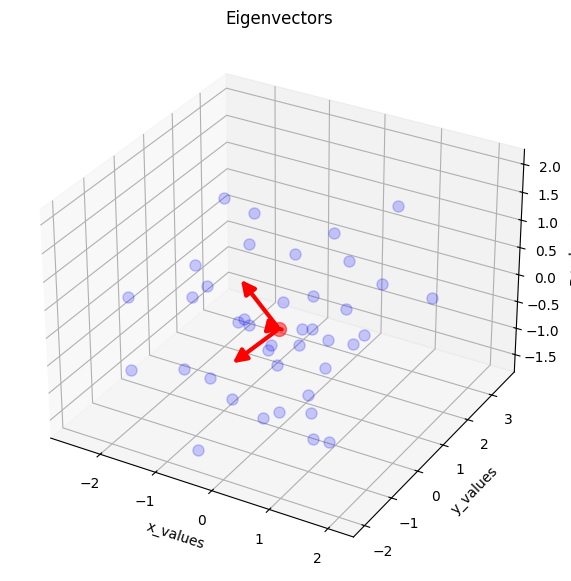

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, ax, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs
        self.ax = ax

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.ax.get_proj()
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):

        xs3d, ys3d, zs3d = self._verts3d

        _, _, zs_projected = proj3d.proj_transform(xs3d, ys3d, zs3d, self.ax.get_proj())
        return (zs_projected[0] + zs_projected[1]) / 2


# Figure
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')


# Data points
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)


# Mean point
ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)


# Eigenvectors
for v in eigan_vector.T:

    a = Arrow3D(
        [df['feature1'].mean(), v[0]],
        [df['feature2'].mean(), v[1]],
        [df['feature3'].mean(), v[2]],
        ax, # Pass the axes object here
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )

    ax.add_artist(a)


# Labels
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [11]:
pc=eigan_vector[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [12]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.429384,0.829265,1
1,-1.124520,0.842226,1
2,0.599433,1.795862,1
3,-0.094556,-0.761566,1
4,-0.401542,1.203061,1


In [13]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()